In [1]:

import os
from statistics import correlation

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import logomaker
import re
from Bio import motifs
from Bio.Data import IUPACData
from Bio.Align import substitution_matrices
from Bio.Seq import Seq
from Bio import Align
from Bio.SeqRecord import SeqRecord
import umap


/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BIM = "DMRPEIWIAQELRRIGDEFNAYYAR"
BID =	"EIAQELRRIGDEFNAYYAR"
PUMA = "EQRNKLELEIGNDEFNAYYAR"
BAD =	"NLWAAQRYGRELRRMSDEFVDSFKK" #	Weak direct BAX binding
HRK =	"LRRIGDKVNLRQKLLNLISKLF"	#Binds groove with lower affinity
BNIP3	= "ELLRAGDDINR"
BAX_BH3 = "DDFSRRYRRDFAEMSGQ"
BAX_helix9 = "VTVLTIFVAGVLTASLTIWKKMG"
natural_binder = {"bh_only"  : [BIM, BID, PUMA], "sensitizer" : [BAD, HRK, BNIP3], "bh_3_bax" : [BAX_BH3], "BAX_helix9" : [BAX_helix9] }
bh_only_list = [BIM, BID, PUMA]


In [3]:
sns.set_palette("colorblind")

In [4]:
def extract_chain_b_sequence(pdb_file_path):
    """
    /home/kunzj/BindCraft_uva_internship/data/sequences/first/
    Parses a PDB file to extract the amino acid sequence of Chain B.

    Returns:
        str: A string of three-letter amino acid codes separated by spaces.
    """
    amino_acids = []
    last_residue_id = None

    # Standard 3-to-1 mapping if a single-letter string is required:
    # d_map = {'GLN':'Q', 'PRO':'P', 'ARG':'R', 'GLY':'G', ...}

    try:
        with open(pdb_file_path, 'r') as f:
            for line in f:
                # ATOM records contain the coordinate and residue data
                if line.startswith("ATOM"):
                    chain_id = line[21].strip()
                    res_name = line[17:20].strip()
                    res_seq_num = line[22:26].strip()

                    # Filter for Chain B and ensure we only count each residue once
                    if chain_id == 'B':
                        if res_seq_num != last_residue_id:
                            amino_acids.append(res_name)
                            last_residue_id = res_seq_num

                # Stop if a TER record or ENDMDL is reached for the chain
                elif line.startswith("TER") and last_residue_id is not None:
                    # If the file contains multiple chains, we only want Chain B
                    # If Chain B is already processed, we can exit
                    if len(amino_acids) > 0:
                        break

        return amino_acids

    except FileNotFoundError:
        return "File not found."

# Example output based on your data:
# "SER VAL ARG GLU LEU THR ARG LEU MET ALA"

In [5]:


def get_all_seq(directory_path):
    seqlist = []

    # Retrieve filenames from the directory
    filenames = os.listdir(directory_path)

    # Sort filenames numerically by extracting the leading integer
    # This regex matches one or more digits at the start of the string
    filenames.sort(key=lambda f: int(re.match(r'\d+', f).group()) if re.match(r'\d+', f) else float('inf'))

    for filename in filenames:
        file_path = os.path.join(directory_path, filename)

        if os.path.isfile(file_path):
            seqlist.append(extract_chain_b_sequence(file_path))
            print(file_path)

    return seqlist


In [6]:
import os
import re
from collections import defaultdict

def get_atom_count(pdb_file_path):
    """
    Parses a PDB file to count the number of each atom type in Chain B.

    Args:
        pdb_file_path (str): Path to the PDB file

    Returns:
        dict: Dictionary with atom names as keys and counts as values
    """
    atom_counts = defaultdict(int)

    try:
        with open(pdb_file_path, 'r') as f:
            for line in f:
                # ATOM records contain the coordinate and atom data
                if line.startswith("ATOM"):
                    chain_id = line[21].strip()
                    atom_name = line[-4].strip()

                    # Filter for Chain B only
                    if chain_id == 'B':
                        atom_counts[atom_name] += 1

                # Stop if a TER record is reached for Chain B
                elif line.startswith("TER"):
                    # Check if we've processed any Chain B atoms
                    if len(atom_counts) > 0:
                        break

        return dict(atom_counts)

    except FileNotFoundError:
        return {"error": "File not found."}

def get_all_atom_counts(directory_path):
    """
    Processes all PDB files in a directory and returns atom counts for Chain B.

    Args:
        directory_path (str): Path to the directory containing PDB files

    Returns:
        list: List of dictionaries containing atom counts for each PDB file
    """
    atom_counts_list = []

    # Retrieve filenames from the directory
    filenames = os.listdir(directory_path)

    # Sort filenames numerically by extracting the leading integer
    # This regex matches one or more digits at the start of the string
    filenames.sort(key=lambda f: int(re.match(r'\d+', f).group()) if re.match(r'\d+', f) else float('inf'))

    for filename in filenames:
        file_path = os.path.join(directory_path, filename)

        if os.path.isfile(file_path) and filename.endswith('.pdb'):
            atom_counts = get_atom_count(file_path)
            atom_counts_list.append(atom_counts)
            print(f"Processed: {file_path}")

    return atom_counts_list

# Example usage:
# atom_counts = get_all_atom_counts("/path/to/pdb/directory/")
# print(atom_counts)


In [7]:
#atom_counts = get_all_atom_counts("/home/kunzj/BindCraft_uva_internship/data/sequences/first/")

In [8]:
def sum_nosc_atoms(atom_counts_list):
    """
    Sums up N, O, S, and C atoms from each atom count dictionary.

    Args:
        atom_counts_list (list): List of dictionaries containing atom counts

    Returns:
        list: List of dictionaries with summed N, O, S, C counts for each PDB file
    """
    summary_list = []

    for atom_counts in atom_counts_list:
        # Initialize counts for this file
        summary = {'N': 0, 'O': 0, 'S': 0, 'C': 0}

        # Sum up the specified atom types
        for atom_name, count in atom_counts.items():
            if atom_name == 'N':
                summary['N'] = count
            elif atom_name == 'O':
                summary['O'] = count
            elif atom_name == 'S':
                summary['S'] = count
            elif atom_name == 'C':
                summary['C'] = count

        summary_list.append(sum(summary.values()))

    return summary_list

# Example usage:
# atom_counts = get_all_atom_counts("/path/to/pdb/directory/")
# nosc_counts = sum_nosc_atoms(atom_counts)
# print(nosc_counts)

# Alternative one-liner version:
def sum_nosc_atoms_one_liner(atom_counts_list):
    """
    One-liner version that sums up N, O, S, and C atoms.
    """
    return [
        {
            'N': atom_dict.get('N', 0),
            'O': atom_dict.get('O', 0),
            'S': atom_dict.get('S', 0),
            'C': atom_dict.get('C', 0)
        }
        for atom_dict in atom_counts_list
    ]


#max(sum_nosc_atoms(atom_counts))

In [9]:
def get_all_seq_list(path):
    """
    Processes all PDB files in a directory and returns a dictionary of sequences,
    with subfolders being the names.

    Args:
        path (str): Path to the directory containing PDB files

    Returns:
        dict: Dictionary of sequences extracted from the PDB files, with subfolders being the names
    """
    sequences_dict = {}

    # Retrieve subfolders from the directory
    subfolders = [f.path for f in os.scandir(path) if f.is_dir()]

    for subfolder in subfolders:
        try:
            # Retrieve filenames from the subfolder
            supath = subfolder + "/Accepted/"

            # Sort filenames numerically by extracting the leading integer
            # This regex matches one or more digits at the start of the string

            sequences = get_all_seq(supath)


            sequences_dict[os.path.basename(subfolder)] = sequences
        except:
            continue
    return sequences_dict


In [10]:
sequences_1  = get_all_seq("/home/kunzj/BindCraft_uva_internship/data/sequences/first/")
sequences_2  = get_all_seq("/home/kunzj/BindCraft_uva_internship/data/sequences/second/")
sequences_3  = get_all_seq("/home/kunzj/BAX_third_iteration/DATA/bindcraft/Accepted/Ranked/")

sequences_gy = get_all_seq_list("/FastHome/gyula/designs/place_holder/DATA/")



/home/kunzj/BindCraft_uva_internship/data/sequences/first/1_BAX_1F16_l12_s251320_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/2_BAX_1F16_l12_s457127_mpnn2_model2.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/3_BAX_1F16_l12_s457127_mpnn3_model2.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/4_BAX_1F16_l12_s251320_mpnn2_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/5_BAX_1F16_l12_s186135_mpnn1_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/6_BAX_1F16_l15_s386933_mpnn2_model2.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/7_BAX_1F16_l13_s587561_mpnn3_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/8_BAX_1F16_l12_s315324_mpnn3_model1.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/9_BAX_1F16_l14_s778504_mpnn1_model2.pdb
/home/kunzj/BindCraft_uva_internship/data/sequences/first/10_BAX_1F16_l14_s778504_mpnn2_model2.pdb
/home/kunzj/BindCra

In [11]:
sequences_gy['gy_2']

[['SER',
  'PRO',
  'ALA',
  'GLN',
  'GLN',
  'GLU',
  'GLY',
  'MET',
  'ASP',
  'LYS',
  'LEU',
  'THR',
  'ALA',
  'TRP',
  'LEU',
  'ARG',
  'SER',
  'PHE'],
 ['SER',
  'SER',
  'GLY',
  'LEU',
  'GLY',
  'LYS',
  'ARG',
  'ILE',
  'TYR',
  'ASP',
  'GLU',
  'VAL',
  'ASP',
  'LYS',
  'LEU',
  'PHE',
  'SER'],
 ['GLY',
  'SER',
  'SER',
  'VAL',
  'ILE',
  'LYS',
  'GLU',
  'VAL',
  'VAL',
  'ASP',
  'ALA',
  'PHE',
  'ARG',
  'ARG'],
 ['ASN',
  'MET',
  'HIS',
  'SER',
  'LEU',
  'THR',
  'GLN',
  'LYS',
  'MET',
  'MET',
  'ASP',
  'ILE',
  'LEU',
  'SER'],
 ['SER',
  'SER',
  'ILE',
  'GLN',
  'HIS',
  'LEU',
  'ALA',
  'GLU',
  'THR',
  'LEU',
  'ARG',
  'ASN',
  'TRP'],
 ['MET',
  'ASP',
  'GLU',
  'THR',
  'ILE',
  'SER',
  'GLN',
  'LEU',
  'ARG',
  'ARG',
  'LEU',
  'MET',
  'TRP',
  'GLU',
  'SER',
  'ILE',
  'ASP',
  'SER',
  'PHE',
  'PHE',
  'LYS',
  'SER',
  'LEU'],
 ['ASN',
  'GLN',
  'SER',
  'ASP',
  'ILE',
  'ASP',
  'TYR',
  'ILE',
  'LEU',
  'ASP',
  'GLU',
  'S

In [12]:
lengths_1 = [*map(len, sequences_1)]
lengths_2 = [*map(len, sequences_2)]
lengths_3 = [*map(len, sequences_3)]


/tmp/ipykernel_319028/3123673823.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
/tmp/ipykernel_319028/3123673823.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


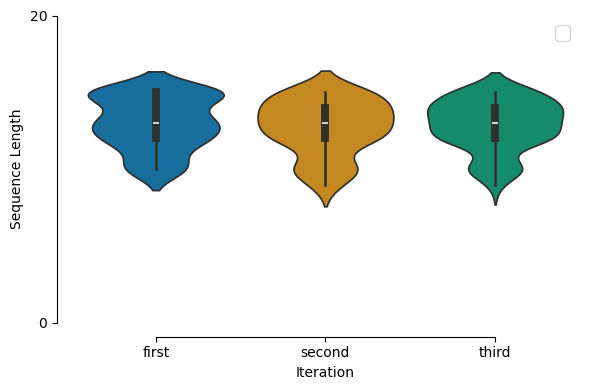

In [13]:

plt.rcdefaults()
lengths_all = pd.DataFrame([lengths_1, lengths_2, lengths_3]).T
lengths_all.columns = ["first", "second", "third"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=lengths_all, palette="colorblind", ax=ax)

# Adjust plot layout
plt.xticks(rotation=45)
plt.xlabel("Iteration")
plt.ylabel("Sequence Length")

# Adjust ticks
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.set_yticks(np.arange(0, lengths_all.values.max() + 20, 20))

# Adjust legend
plt.legend(fontsize=14)

# Adjust grid
sns.despine(offset=10, trim=True)

# Adjust overall plot
plt.tight_layout()

# Show plot
plt.show()
#lengths_all

In [14]:
aa_map = {

        'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',

        'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',

        'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',

        'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'

    }

aa_map_inverse =  {v: k for k, v in aa_map.items()}


In [15]:
sequences_gy

{'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15': [[],
  ['SER',
   'TRP',
   'VAL',
   'ASP',
   'LYS',
   'VAL',
   'VAL',
   'GLU',
   'ILE',
   'LEU',
   'ASP',
   'SER',
   'LEU',
   'ARG',
   'SER'],
  ['THR',
   'TRP',
   'TRP',
   'GLU',
   'PHE',
   'VAL',
   'ASP',
   'GLN',
   'TYR',
   'LEU',
   'SER',
   'ASN',
   'GLN',
   'HIS',
   'ALA'],
  ['SER',
   'LEU',
   'MET',
   'ASP',
   'GLU',
   'ILE',
   'GLU',
   'GLU',
   'ALA',
   'PHE',
   'ARG',
   'ARG',
   'ALA',
   'LEU',
   'ARG'],
  ['PHE',
   'LYS',
   'LYS',
   'ILE',
   'TRP',
   'ASN',
   'LYS',
   'MET',
   'MET',
   'ASP',
   'VAL',
   'LEU',
   'ASN',
   'GLN',
   'LEU'],
  ['ASP',
   'LEU',
   'GLY',
   'SER',
   'GLU',
   'LEU',
   'GLY',
   'ARG',
   'PHE',
   'PHE',
   'LYS',
   'GLU',
   'LEU',
   'THR',
   'ASP'],
  ['SER',
   'ILE',
   'SER',
   'GLN',
   'ILE',
   'VAL',
   'GLN',
   'GLU',
   'ALA',
   'ILE',
   'ASN',
   'SER',
   'PHE',
   'PRO',
   'SER'],
  ['SER',
   'ILE',
   'GLU',
  

In [16]:
bh_dict = {}
for key in natural_binder.keys():
    bh_list = map(list,natural_binder[key])
    bh_list_new = []
    for bh_list_element in bh_list:
        bh_list_element_new = [aa_map_inverse[x] for x in bh_list_element]
        bh_list_new.append(bh_list_element_new)
    bh_dict[key] = list(bh_list_new)
bh_dict

{'bh_only': [['ASP',
   'MET',
   'ARG',
   'PRO',
   'GLU',
   'ILE',
   'TRP',
   'ILE',
   'ALA',
   'GLN',
   'GLU',
   'LEU',
   'ARG',
   'ARG',
   'ILE',
   'GLY',
   'ASP',
   'GLU',
   'PHE',
   'ASN',
   'ALA',
   'TYR',
   'TYR',
   'ALA',
   'ARG'],
  ['GLU',
   'ILE',
   'ALA',
   'GLN',
   'GLU',
   'LEU',
   'ARG',
   'ARG',
   'ILE',
   'GLY',
   'ASP',
   'GLU',
   'PHE',
   'ASN',
   'ALA',
   'TYR',
   'TYR',
   'ALA',
   'ARG'],
  ['GLU',
   'GLN',
   'ARG',
   'ASN',
   'LYS',
   'LEU',
   'GLU',
   'LEU',
   'GLU',
   'ILE',
   'GLY',
   'ASN',
   'ASP',
   'GLU',
   'PHE',
   'ASN',
   'ALA',
   'TYR',
   'TYR',
   'ALA',
   'ARG']],
 'sensitizer': [['ASN',
   'LEU',
   'TRP',
   'ALA',
   'ALA',
   'GLN',
   'ARG',
   'TYR',
   'GLY',
   'ARG',
   'GLU',
   'LEU',
   'ARG',
   'ARG',
   'MET',
   'SER',
   'ASP',
   'GLU',
   'PHE',
   'VAL',
   'ASP',
   'SER',
   'PHE',
   'LYS',
   'LYS'],
  ['LEU',
   'ARG',
   'ARG',
   'ILE',
   'GLY',
   'ASP',
   'LYS',


In [17]:
sequences_1

[['THR',
  'LEU',
  'GLY',
  'GLU',
  'ARG',
  'ILE',
  'LEU',
  'ALA',
  'GLU',
  'VAL',
  'ASN',
  'LYS'],
 ['SER',
  'LEU',
  'GLY',
  'ASP',
  'THR',
  'ILE',
  'LEU',
  'GLU',
  'GLU',
  'VAL',
  'MET',
  'LYS'],
 ['SER',
  'LEU',
  'GLY',
  'ASP',
  'THR',
  'ILE',
  'LEU',
  'ASN',
  'GLU',
  'VAL',
  'MET',
  'LYS'],
 ['THR',
  'LEU',
  'GLY',
  'GLU',
  'ARG',
  'ILE',
  'LEU',
  'GLU',
  'GLU',
  'VAL',
  'ASN',
  'LYS'],
 ['SER',
  'LEU',
  'GLY',
  'GLN',
  'GLU',
  'ILE',
  'LEU',
  'LYS',
  'GLU',
  'VAL',
  'GLU',
  'LYS'],
 ['ASP',
  'MET',
  'GLU',
  'LYS',
  'LEU',
  'THR',
  'LYS',
  'ASP',
  'ALA',
  'TYR',
  'ASP',
  'ALA',
  'LEU',
  'MET',
  'SER'],
 ['ASP',
  'PRO',
  'GLU',
  'ASP',
  'VAL',
  'GLU',
  'ALA',
  'THR',
  'LEU',
  'LYS',
  'LYS',
  'ALA',
  'LEU'],
 ['ASP',
  'LEU',
  'LYS',
  'GLU',
  'LEU',
  'GLY',
  'GLU',
  'MET',
  'LEU',
  'ARG',
  'SER',
  'LEU'],
 ['ASN',
  'LEU',
  'SER',
  'ASP',
  'VAL',
  'GLU',
  'TYR',
  'SER',
  'LEU',
  'ARG',
  

In [18]:


seq_dict_all = sequences_gy
seq_dict_all["Johnatan_i1"] = sequences_1
seq_dict_all["Johnatan_i2"] = sequences_2
seq_dict_all["Johnatan_i3"] = sequences_3
seq_dict_all.update(bh_dict)


In [19]:

# Convert dict to list of tuples
sequences_all = [(val, k) for k, values in seq_dict_all.items() for val in values]


In [20]:
sequences_all

[([], 'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15'),
 (['SER',
   'TRP',
   'VAL',
   'ASP',
   'LYS',
   'VAL',
   'VAL',
   'GLU',
   'ILE',
   'LEU',
   'ASP',
   'SER',
   'LEU',
   'ARG',
   'SER'],
  'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15'),
 (['THR',
   'TRP',
   'TRP',
   'GLU',
   'PHE',
   'VAL',
   'ASP',
   'GLN',
   'TYR',
   'LEU',
   'SER',
   'ASN',
   'GLN',
   'HIS',
   'ALA'],
  'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15'),
 (['SER',
   'LEU',
   'MET',
   'ASP',
   'GLU',
   'ILE',
   'GLU',
   'GLU',
   'ALA',
   'PHE',
   'ARG',
   'ARG',
   'ALA',
   'LEU',
   'ARG'],
  'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15'),
 (['PHE',
   'LYS',
   'LYS',
   'ILE',
   'TRP',
   'ASN',
   'LYS',
   'MET',
   'MET',
   'ASP',
   'VAL',
   'LEU',
   'ASN',
   'GLN',
   'LEU'],
  'gy_2nd_iter_try_29_balm_deployed_weight_10_length_15'),
 (['ASP',
   'LEU',
   'GLY',
   'SER',
   'GLU',
   'LEU',
   'GLY',
   'ARG',
   'PHE',
   'PHE

In [21]:



# Sample input

def to_sequences(list_sequences, iter):
# Mapping dictionary

    aa_map = {

        'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',

        'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',

        'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',

        'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'

    }



    # Convert to SeqRecord objects

    sequences = [SeqRecord(Seq("".join([aa_map[aa] for aa in p])), description= iter, id= f"{iter}_{i + 1}th_rank") for i, p in enumerate(list_sequences)]

    #
    #
    # aligner = Align.PairwiseAligner()
    #
    # aligner.mode = 'global'
    #
    # alignments = aligner.align(sequences[0].seq, sequences[1].seq)
    #
    # best_alignment = alignments[0]
    return sequences



In [22]:

seq_all = []
for k, v in seq_dict_all.items():
    seq_all.extend(to_sequences(v, k))

In [23]:
seq_all

[SeqRecord(seq=Seq(''), id='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15_1th_rank', name='<unknown name>', description='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15', dbxrefs=[]),
 SeqRecord(seq=Seq('SWVDKVVEILDSLRS'), id='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15_2th_rank', name='<unknown name>', description='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15', dbxrefs=[]),
 SeqRecord(seq=Seq('TWWEFVDQYLSNQHA'), id='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15_3th_rank', name='<unknown name>', description='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15', dbxrefs=[]),
 SeqRecord(seq=Seq('SLMDEIEEAFRRALR'), id='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15_4th_rank', name='<unknown name>', description='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15', dbxrefs=[]),
 SeqRecord(seq=Seq('FKKIWNKMMDVLNQL'), id='gy_2nd_iter_try_29_balm_deployed_weight_10_length_15_5th_rank', name='<unknown name>', description='gy_2nd_iter_try_29_balm_depl

In [24]:
 substitution_matrices.load("BLOSUM62")

Array([[ 4., -1., -2., -2.,  0., -1., -1.,  0., -2., -1., -1., -1., -1.,
        -2., -1.,  1.,  0., -3., -2.,  0., -2., -1.,  0., -4.],
       [-1.,  5.,  0., -2., -3.,  1.,  0., -2.,  0., -3., -2.,  2., -1.,
        -3., -2., -1., -1., -3., -2., -3., -1.,  0., -1., -4.],
       [-2.,  0.,  6.,  1., -3.,  0.,  0.,  0.,  1., -3., -3.,  0., -2.,
        -3., -2.,  1.,  0., -4., -2., -3.,  3.,  0., -1., -4.],
       [-2., -2.,  1.,  6., -3.,  0.,  2., -1., -1., -3., -4., -1., -3.,
        -3., -1.,  0., -1., -4., -3., -3.,  4.,  1., -1., -4.],
       [ 0., -3., -3., -3.,  9., -3., -4., -3., -3., -1., -1., -3., -1.,
        -2., -3., -1., -1., -2., -2., -1., -3., -3., -2., -4.],
       [-1.,  1.,  0.,  0., -3.,  5.,  2., -2.,  0., -3., -2.,  1.,  0.,
        -3., -1.,  0., -1., -2., -1., -2.,  0.,  3., -1., -4.],
       [-1.,  0.,  0.,  2., -4.,  2.,  5., -2.,  0., -3., -3.,  1., -2.,
        -3., -1.,  0., -1., -3., -2., -2.,  1.,  4., -1., -4.],
       [ 0., -2.,  0., -1., -3., -2., -2.

In [25]:

def create_my_aligner(BLOSUM=True, gap_penalty = -10):
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'

    if BLOSUM:


        aligner.substitution_matrix = substitution_matrices.load("BLOSUM80")
        aligner.open_gap_score = gap_penalty * 2
        aligner.extend_gap_score = gap_penalty

    aligner.end_insertion_score = 0
    aligner.end_deletion_score = 0
    return aligner

def find_central_sequence(sequences, BLOSUM=True):
    num_seqs = len(sequences)
    # Matrix to store scores
    score_matrix = np.zeros((num_seqs, num_seqs))
    aligner = create_my_aligner(BLOSUM=BLOSUM)


    for i in range(num_seqs):
        for j in range(i + 1, num_seqs):
            score = aligner.score(sequences[i].seq, sequences[j].seq)
            score_matrix[i, j] = score
            score_matrix[j, i] = score

    # Sum scores for each sequence across all pairs
    total_scores = score_matrix.sum(axis=1)
    # The 'center' is the index with the highest cumulative score
    center_idx = np.argmax(total_scores)
    return center_idx, score_matrix

# GAPS MAY NOT BE PROPAGATED CORRECTLY
# def STAR_MSA_Central(sequences, BLOSUM=True):
#
#     aligner = create_my_aligner(BLOSUM=BLOSUM)
#
#     # Step 1: Find the best biological template
#     center_idx,_ = find_central_sequence(sequences, aligner)
#     template = sequences[center_idx].seq
#
#     aligned_set = []
#
#     # Step 2: Align all sequences to the central template
#     for s in sequences:
#         # We align the template to the sequence; alignment[1] is the query
#         alignment = aligner.align(template, s.seq)[0]
#         aligned_set.append(str(alignment[1]))
#
#     return aligned_set



def pad_aligned_sequences(aligned_set, pad_char="-"):
    # Determine the maximum length among aligned sequences
    max_len = max(len(s) for s in aligned_set)

    # Pad each sequence to the right to reach max_len
    padded_set = [s.ljust(max_len, pad_char) for s in aligned_set]

    return padded_set

import numpy as np

def propagate_gaps(msa_dict, ref_id, new_id, aligned_ref, aligned_new):
    msa_ref = msa_dict[ref_id]
    new_msa = {k: "" for k in msa_dict.keys()}
    new_seq = ""

    i, j = 0, 0
    while i < len(msa_ref) or j < len(aligned_ref):
        # Condition 1: Concurrent gaps. Merge insertions at the identical reference coordinate.
        if i < len(msa_ref) and j < len(aligned_ref) and msa_ref[i] == '-' and aligned_ref[j] == '-':
            for k in msa_dict:
                new_msa[k] += msa_dict[k][i]
            new_seq += aligned_new[j]
            i += 1
            j += 1

        # Condition 2: Gap exists strictly within the pre-compiled MSA.
        elif i < len(msa_ref) and msa_ref[i] == '-':
            for k in msa_dict:
                new_msa[k] += msa_dict[k][i]
            new_seq += '-'
            i += 1

        # Condition 3: Gap introduced strictly by the new pairwise alignment.
        elif j < len(aligned_ref) and aligned_ref[j] == '-':
            for k in msa_dict:
                new_msa[k] += '-'
            new_seq += aligned_new[j]
            j += 1

        # Condition 4: Substitution/Match state sequence advancing.
        else:
            for k in msa_dict:
                new_msa[k] += msa_dict[k][i]
            new_seq += aligned_new[j]
            i += 1
            j += 1

    msa_dict = new_msa
    msa_dict[new_id] = new_seq
    return msa_dict

def Progressive_MSA(sequences, BLOSUM=True, gap_penalty = -10):
    aligner = create_my_aligner(BLOSUM=BLOSUM, gap_penalty= gap_penalty)
    n = len(sequences)

    # Step 1: Compute pairwise distance matrix
    scores = np.zeros((n, n))
    alignments = {}

    for i in range(n):
        for j in range(i + 1, n):
            aln = aligner.align(sequences[i].seq, sequences[j].seq)[0]
            scores[i, j] = scores[j, i] = aln.score

            # Store alignments bidirectionally based on user's assumed API
            alignments[(i, j)] = (str(aln[0]), str(aln[1]))
            alignments[(j, i)] = (str(aln[1]), str(aln[0]))

    # Step 2: Initialize MSA with the closest pair
    max_idx = np.unravel_index(np.argmax(scores), scores.shape)
    id1, id2 = max_idx

    msa = {
        id1: alignments[(id1, id2)][0],
        id2: alignments[(id1, id2)][1]
    }
    unaligned = set(range(n)) - {id1, id2}

    # Step 3: Greedy topology addition
    while unaligned:
        best_score = -float('inf')
        best_pair = None

        # Identify the highest scoring link between the unaligned pool and MSA pool
        for u in unaligned:
            for a in msa.keys():
                if scores[u, a] > best_score:
                    best_score = scores[u, a]
                    best_pair = (u, a)

        new_id, ref_id = best_pair

        aln_ref = alignments[(ref_id, new_id)][0]
        aln_new = alignments[(ref_id, new_id)][1]

        # Step 4: Bidirectional gap propagation
        msa = propagate_gaps(msa, ref_id, new_id, aln_ref, aln_new)
        unaligned.remove(new_id)

    # Reorder the dictionary output to match the original input index
    return [msa[i] for i in range(n)]

def get_relative_offset(aligned_ref, aligned_new):
    """
    Calculates the 1D coordinate shift of the new sequence relative to the reference.
    Positive value: new sequence starts right (downstream) of the reference.
    Negative value: new sequence starts left (upstream) of the reference.
    """
    ref_start = len(aligned_ref) - len(aligned_ref.lstrip('-'))
    new_start = len(aligned_new) - len(aligned_new.lstrip('-'))
    return new_start - ref_start

def Progressive_MSA_Rigid(sequences, BLOSUM=True, gap_penalty = -10):
    aligner = create_my_aligner(BLOSUM=BLOSUM, gap_penalty= gap_penalty)
    n = len(sequences)

    # 1. Compute pairwise distance matrix and generate rigid alignments
    scores = np.zeros((n, n))
    alignments = {}

    for i in range(n):
        for j in range(i + 1, n):
            aln = aligner.align(sequences[i].seq, sequences[j].seq)[0]
            scores[i, j] = scores[j, i] = aln.score

            alignments[(i, j)] = (str(aln[0]), str(aln[1]))
            alignments[(j, i)] = (str(aln[1]), str(aln[0]))

    # 2. Initialize global origin with the highest scoring pair
    max_idx = np.unravel_index(np.argmax(scores), scores.shape)
    id1, id2 = max_idx

    global_offsets = {id1: 0}
    global_offsets[id2] = get_relative_offset(alignments[(id1, id2)][0], alignments[(id1, id2)][1])

    aligned_pool = {id1, id2}
    unaligned_pool = set(range(n)) - aligned_pool

    # 3. Greedy topology addition via translation vectors
    while unaligned_pool:
        best_score = -float('inf')
        best_pair = None

        for u in unaligned_pool:
            for a in aligned_pool:
                if scores[u, a] > best_score:
                    best_score = scores[u, a]
                    best_pair = (u, a)

        new_id, ref_id = best_pair

        aln_ref = alignments[(ref_id, new_id)][0]
        aln_new = alignments[(ref_id, new_id)][1]

        # Calculate new coordinate relative to the global offset of the reference
        rel_offset = get_relative_offset(aln_ref, aln_new)
        global_offsets[new_id] = global_offsets[ref_id] + rel_offset

        aligned_pool.add(new_id)
        unaligned_pool.remove(new_id)

    # 4. Matrix Assembly: Normalize coordinates to absolute zero and apply global padding
    min_offset = min(global_offsets.values())
    for k in global_offsets:
        global_offsets[k] -= min_offset

    msa_length = max(global_offsets[k] + len(sequences[k]) for k in range(n))

    # 5. Output mapping ordered by original input indices
    aligned_set = []
    for k in range(n):
        seq_str = str(sequences[k].seq)
        left_pad = '-' * global_offsets[k]
        right_pad = '-' * (msa_length - len(seq_str) - global_offsets[k])
        aligned_set.append(left_pad + seq_str + right_pad)

    return aligned_set


In [26]:







# Define the full protein alphabet (20 standard amino acids)

def logoplot_with_gaps(padded_star):
    # 1. Compute Matrix Variables
    num_seqs = len(padded_star)
    seq_length = len(padded_star[0])

    # Calculate independent gap frequencies per column
    gap_counts = np.zeros(seq_length)
    for seq in padded_star:
        for i, char in enumerate(seq):
            if char == '-':
                gap_counts[i] += 1
    gap_frequencies = gap_counts / num_seqs

    # Standard Biopython motif generation
    protein_alphabet = IUPACData.protein_letters
    instances = [Seq(s) for s in padded_star]
    m = motifs.create(instances, alphabet=protein_alphabet)

    pfm = m.counts
    pwm = pfm.normalize(pseudocounts=0.5)
    df = pd.DataFrame(pwm)

    # 2. Subplot Architecture
    # Initialize a 2-panel figure sharing the x-axis
    fig, (ax_logo, ax_gaps) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # 3. Render Sequence Logo (Top Panel)
    logo = logomaker.Logo(df,
                          color_scheme='chemistry',
                          stack_order='small_on_top',
                          ax=ax_logo)

    logo.style_spines(visible=False)
    logo.style_spines(spines=('left', 'bottom'), visible=True)
    logo.ax.set_ylabel("Probability")
    logo.ax.set_title("Peptide Sequence Logo")

    # 4. Render Gap Density (Bottom Panel)
    # Using a bar plot to map exact positional density
    ax_gaps.bar(range(seq_length), gap_frequencies, color='gray', alpha=0.6)

    ax_gaps.set_ylabel("Gap Frequency")
    ax_gaps.set_xlabel("Position")
    ax_gaps.set_ylim(0, 1.0)

    # Align grid spacing for visual clarity
    ax_gaps.spines['top'].set_visible(False)
    ax_gaps.spines['right'].set_visible(False)
    ax_logo.grid(False)
    ax_gaps.grid(False)
    plt.tight_layout()
    plt.show()


In [57]:
%%sql


In [27]:
progressive_all = Progressive_MSA_Rigid(seq_all, gap_penalty=-100000000)


# 46 with gap penalty
# 30 with very high gap penalty


ValueError: sequence has zero length

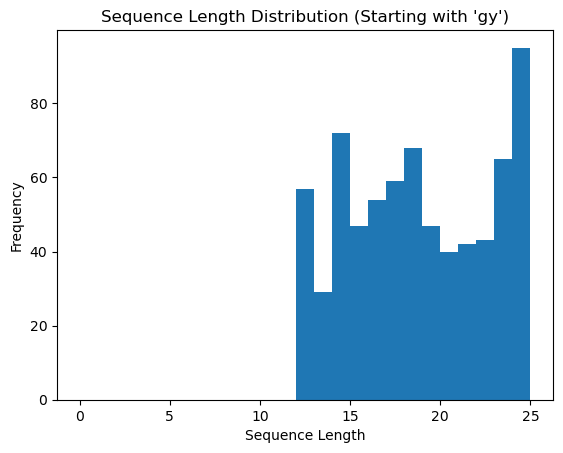

In [25]:
# Plot sequence length distribution
lengths = [len([c for c in s if c != '-']) for s in seq_all if s.description.startswith('gy')]
plt.hist(lengths, bins=np.arange(0, max(lengths) + 1))
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Sequence Length Distribution (Starting with 'gy')")
plt.show()

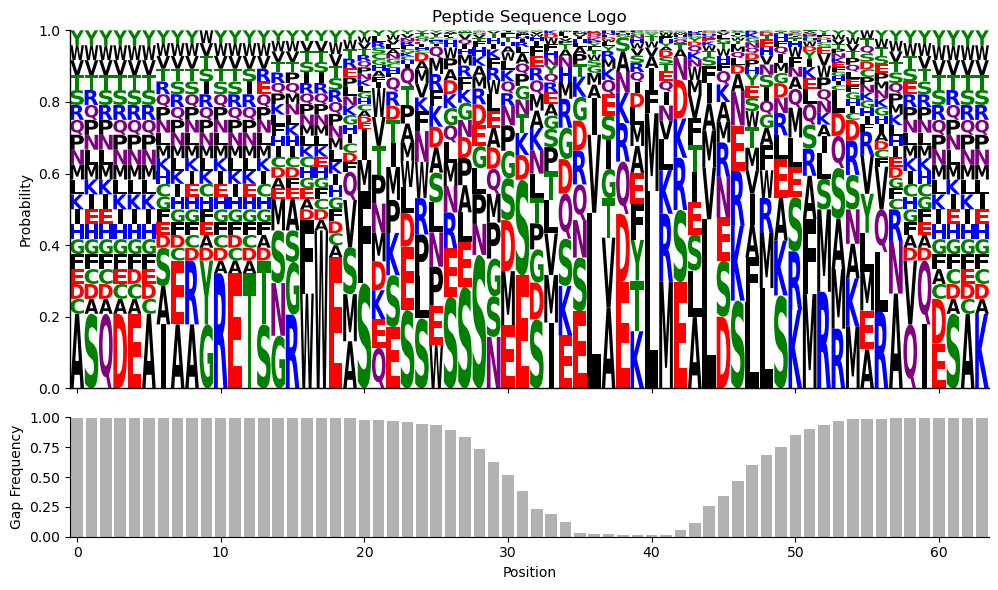

In [26]:
logoplot_with_gaps(progressive_all)

In [54]:
john_sequences[0:204]

[SeqRecord(seq=Seq('TLGERILAEVNK'), id='Johnatan_i1_1th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-60.67044444444444)),
 SeqRecord(seq=Seq('SLGDTILEEVMK'), id='Johnatan_i1_2th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-64.45555555555556)),
 SeqRecord(seq=Seq('SLGDTILNEVMK'), id='Johnatan_i1_3th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-62.51111111111112)),
 SeqRecord(seq=Seq('TLGERILEEVNK'), id='Johnatan_i1_4th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-61.56822222222224)),
 SeqRecord(seq=Seq('SLGQEILKEVEK'), id='Johnatan_i1_5th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-65.88044444444444)),
 SeqRecord(seq=Seq('DMEKLTKDAYDALMS'), id='Johnatan_i1_6th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=np.float64(-76.98222222222223)),
 SeqRecord(seq=Seq('DPEDVEATLKKAL'), id='Johnatan_i1_7th_rank', name='<un

In [60]:
_ ,dist_john = find_central_sequence(john_sequences[0:204])

pd.DataFrame(dist_john).to_csv("/FastHome/gyula/johnathan_distances.csv")


[SeqRecord(seq=Seq('PPNPKNLETVATLKKGLE'), id='gy_13_mut_20_1th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('GDNSTKQVADTMMNAL'), id='gy_13_mut_20_2th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('SDGAKHSQLAAMMNSFFD'), id='gy_13_mut_20_3th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('MSKYEKLGQTLRSL'), id='gy_13_mut_20_4th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('DPELVTKEVLETFFKSKETMAKM'), id='gy_13_mut_20_5th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('SPQELAEALLRW'), id='gy_13_mut_20_6th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('SKHVEEIKRIWVET'), id='gy_13_mut_20_7th_rank', name='<unknown name>', description='gy_13_mut_20', dbxrefs=[]),
 SeqRecord(seq=Seq('NPMEDIQALEDALRN'), id='gy_13_mut_20_8th_rank', name='

In [28]:
seq_all = [s for s in seq_all if len(s.seq) > 0]
center , distance_matrix= find_central_sequence(seq_all)


In [29]:
print(seq_all[1].description)

gy_13_mut_20


In [29]:
reducer = umap.UMAP(metric='precomputed', n_neighbors=50)
# Generate the low-dimensional embedding
embedding = reducer.fit_transform(distance_matrix)

/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


In [54]:
all_ids = [record.id for record in seq_all]
all_iteration = [record.description for record in seq_all]
proteina = [record.seq for record in seq_all]
df_umap = pd.DataFrame({
    'id': all_ids,
    'iteration': all_iteration,
    'UMAP1': embedding[:,0],
    'UMAP2': embedding[:,1],
    "Sequence" : proteina

})

In [47]:
seq_all_lengths = [len(s.seq) for s in seq_all]

In [55]:
df_umap.Sequence = df_umap.Sequence.str.join("")

In [56]:
df_umap

df_aug = pd.concat([pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_5/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_0/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_4/mpnn_design_stats_augmented_with_ntoc.csv"), pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_7/mpnn_design_stats_augmented_with_ntoc.csv")])

df_umap = df_umap.merge(df_aug, how = "inner", on = "Sequence")

0      1.0
1      1.0
2      1.0
3      0.0
4      0.0
      ... 
612    1.0
613    0.0
614    0.0
615    0.0
616    0.0
Name: n_to_c, Length: 617, dtype: float64

In [52]:
df_umap["length"] = seq_all_lengths

df_umap.loc[(df_umap["iteration"] == "gy_0") |
            (df_umap["iteration"] == "gy_2") |
            (df_umap["iteration"] == "gy_4") |
            (df_umap["iteration"] == "gy_7") |
            (df_umap["iteration"] == "gy_5"), "gen_type"] = "long"

df_umap.loc[(df_umap["iteration"] == "Johnatan_i1") |
            (df_umap["iteration"] == "Johnatan_i2") |
            (df_umap["iteration"] == "Johnatan_i3"), "gen_type"] = "short"

df_umap.loc[df_umap["iteration"] == "gy_11_mut_5","gen_type"] = "long_4_stage"


ValueError: Length of values (1655) does not match length of index (617)

In [35]:
df_umap["iteration"].unique()

<StringArray>
['gy_2nd_iter_try_29_balm_deployed_weight_10_length_15',
                                   'gy_13_maybe_mut_20',
                                            'gy_0_test',
                                                 'gy_4',
                     'gy_2nd_iter_try_23_balm_deployed',
                                          'gy_11_mut_5',
          'gy_2nd_iter_try_24_control_interface_fixing',
                                                 'gy_0',
                                                 'gy_7',
                                        'gy_2nd_iter_1',
                                                 'gy_5',
                                                 'gy_2',
                                      'gy_14_more_iter',
                                          'Johnatan_i1',
                                          'Johnatan_i2',
                                          'Johnatan_i3',
                                              'bh_only',
                 

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

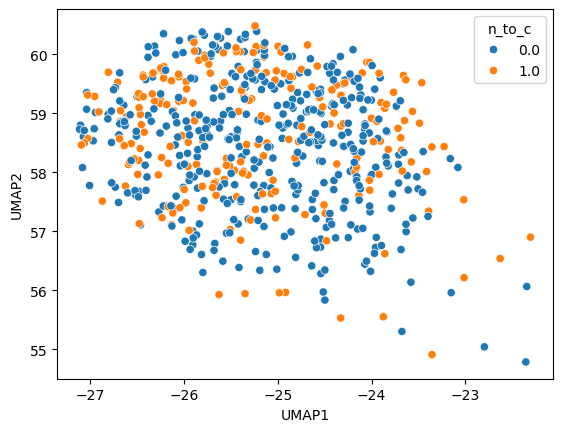

In [64]:
sns.scatterplot(df_umap, x = "UMAP1", y= "UMAP2", hue = "n_to_c")

/tmp/ipykernel_319028/2632037468.py:31: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


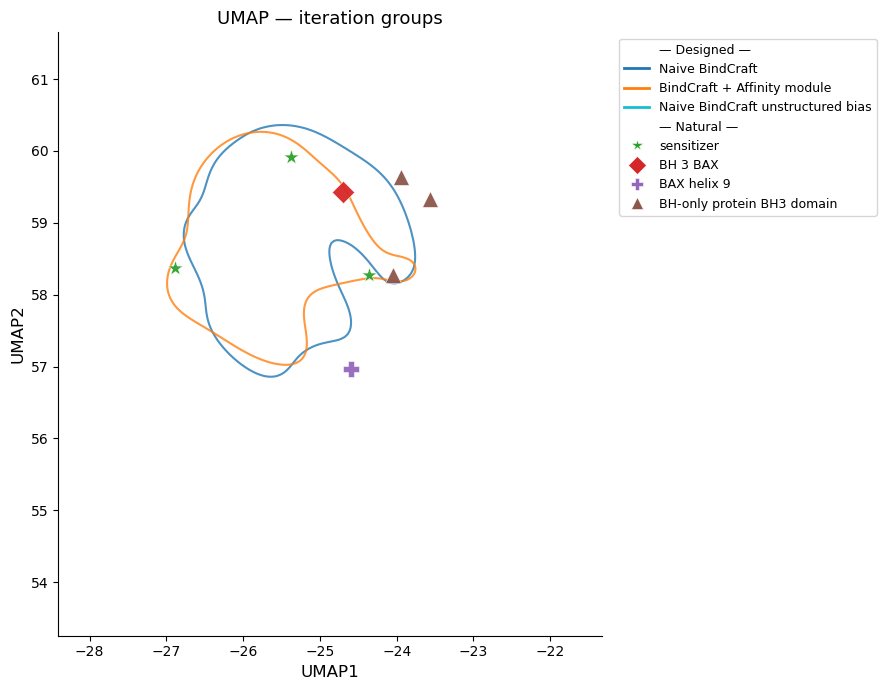

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

# --- Group definitions ---
gy_main = ['gy_13_mut_20', 'gy_4', 'gy_11_mut_5',
           'gy_0', 'gy_7', 'gy_5', 'gy_2', 'gy_14_more_iter',
           'Johnatan_i1', 'Johnatan_i2', 'Johnatan_i3']

non_natural_groups = {
    'Naive BindCraft':                   (gy_main,              '#1f77b4'),
    'BindCraft + Affinity module':       (['gy_2nd_iter_1'],    '#ff7f0e'),
    'Naive BindCraft unstructured bias': (['gy_16_beta'],       '#17becf'),
}

# Using the original df names, but displaying new labels
natural_groups = {
    'sensitizer': ('sensitizer',             '#2ca02c', '*'),
    'BH 3 BAX':   ('bh_3_bax',              '#d62728', 'D'),
    'BAX helix 9':('BAX_helix9',            '#9467bd', 'P'),
    'BH-only protein BH3 domain': ('bh_only','#8c564b', '^'),
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 7))

# 1. KDE contour lines
for label, (members, color) in non_natural_groups.items():
    subset = df_umap[df_umap['iteration'].isin(members)]
    sns.kdeplot(
        data=subset, x='UMAP1', y='UMAP2',
        fill=False, alpha=0.8, color=color,
        thresh=0.5, levels=2, linewidths=1.5,
        ax=ax, zorder=2
    )

# 2. Natural: scatter on top — use df name to filter, display label for legend
for display_label, (df_name, color, marker) in natural_groups.items():
    subset = df_umap[df_umap['iteration'] == df_name]
    ax.scatter(
        subset['UMAP1'], subset['UMAP2'],
        c=color, s=130, marker=marker,
        edgecolors='white', linewidths=0.4,
        alpha=0.95, zorder=4
    )

# --- Manual legend ---
kde_handles = [
    mlines.Line2D([], [], color=color, linewidth=2, label=label)
    for label, (_, color) in non_natural_groups.items()
]

scatter_handles = [
    mlines.Line2D([], [], color=color, marker=marker, linestyle='None',
                  markersize=9, markeredgecolor='white', markeredgewidth=0.4,
                  label=display_label)
    for display_label, (_, color, marker) in natural_groups.items()
]

kde_title     = mpatches.Patch(visible=False, label='— Designed —')
natural_title = mpatches.Patch(visible=False, label='— Natural —')

ax.legend(
    handles=[kde_title] + kde_handles + [natural_title] + scatter_handles,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    frameon=True, fontsize=9, title_fontsize=10,
    title=''
)

ax.set_xlabel('UMAP1', fontsize=12)
ax.set_ylabel('UMAP2', fontsize=12)
ax.set_title('UMAP — iteration groups', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1812747/3042142622.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x='Group', y='Score',


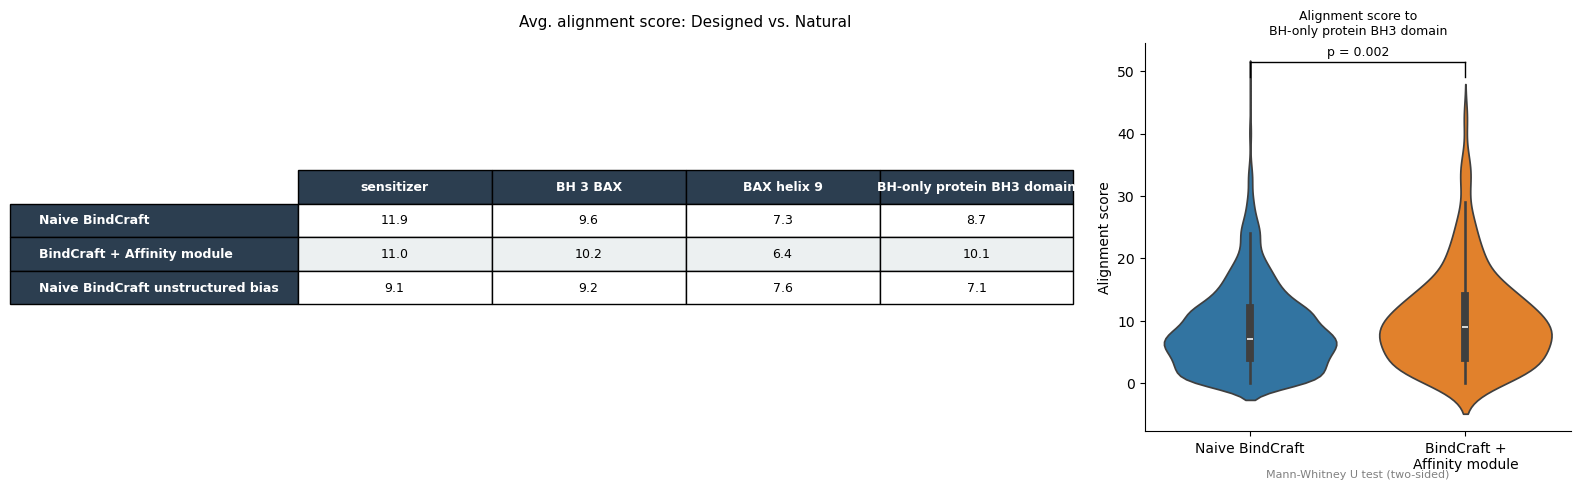

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# --- Group definitions ---
gy_main = ['gy_13_mut_20', 'gy_4', 'gy_11_mut_5',
           'gy_0', 'gy_7', 'gy_5', 'gy_2', 'gy_14_more_iter',
           'Johnatan_i1', 'Johnatan_i2', 'Johnatan_i3']

designed_groups = {
    'Naive BindCraft':                  gy_main,
    'BindCraft + Affinity module':       ['gy_2nd_iter_1'],
    'Naive BindCraft unstructured bias': ['gy_16_beta'],
}

natural_groups = {
    'sensitizer':                 'sensitizer',
    'BH 3 BAX':                   'bh_3_bax',
    'BAX helix 9':                'BAX_helix9',
    'BH-only protein BH3 domain': 'bh_only',
}

# --- Map indices to groups ---
descriptions = [s.description for s in seq_all]

def get_group(desc):
    for label, members in designed_groups.items():
        if desc in members:
            return label
    for display, df_name in natural_groups.items():
        if desc == df_name:
            return display
    return None

groups = [get_group(d) for d in descriptions]
df_dist = pd.DataFrame(distance_matrix, columns=groups, index=groups)

# --- Average table ---
designed_labels = list(designed_groups.keys())
natural_labels  = list(natural_groups.keys())

heatmap_data = pd.DataFrame(index=designed_labels, columns=natural_labels, dtype=float)

for des in designed_labels:
    for nat in natural_labels:
        vals = df_dist.loc[des, nat]
        if isinstance(vals, pd.DataFrame):
            heatmap_data.loc[des, nat] = vals.values.mean()
        elif isinstance(vals, pd.Series):
            heatmap_data.loc[des, nat] = vals.mean()
        else:
            heatmap_data.loc[des, nat] = float(vals)

# --- Extract raw distances for violin ---
def get_vals(des, nat):
    vals = df_dist.loc[des, nat]
    if isinstance(vals, pd.DataFrame):
        return vals.values.flatten()
    elif isinstance(vals, pd.Series):
        return vals.values
    else:
        return np.array([float(vals)])

naive_vals    = get_vals('Naive BindCraft',             'BH-only protein BH3 domain')
affinity_vals = get_vals('BindCraft + Affinity module', 'BH-only protein BH3 domain')

# --- Mann-Whitney U test (nonparametric) ---
u_stat, p_val = stats.mannwhitneyu(naive_vals, affinity_vals, alternative='two-sided')

# --- Figure: table + violin side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [1.4, 1]})

# ── Left: table ──
ax_t = axes[0]
ax_t.axis('off')
table = ax_t.table(
    cellText=[[f"{heatmap_data.loc[r, c]:.1f}" for c in natural_labels] for r in designed_labels],
    rowLabels=designed_labels,
    colLabels=natural_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.3, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#ecf0f1' if row % 2 == 0 else 'white')

ax_t.set_title('Avg. alignment score: Designed vs. Natural', fontsize=11, pad=12)

# ── Right: violin ──
ax_v = axes[1]
violin_df = pd.DataFrame({
    'Score': np.concatenate([naive_vals, affinity_vals]),
    'Group': ['Naive BindCraft'] * len(naive_vals) +
             ['BindCraft +\nAffinity module'] * len(affinity_vals)
})

sns.violinplot(data=violin_df, x='Group', y='Score',
               palette=['#1f77b4', '#ff7f0e'], inner='box', ax=ax_v)

# p-value bracket
y_max  = max(naive_vals.max(), affinity_vals.max())
y_line = y_max * 1.05
ax_v.plot([0, 1], [y_line, y_line], color='black', linewidth=1)
ax_v.plot([0, 0], [y_max,  y_line], color='black', linewidth=1)
ax_v.plot([1, 1], [y_max,  y_line], color='black', linewidth=1)

p_text = f"p = {p_val:.3e}" if p_val < 0.001 else f"p = {p_val:.3f}"
sig    = "***" if p_val < 0.001 else "" if p_val < 0.01 else "" if p_val < 0.05 else "ns"
ax_v.text(0.5, y_line * 1.01, f"{sig}\n{p_text}", ha='center', va='bottom', fontsize=9)

ax_v.set_title('Alignment score to\nBH-only protein BH3 domain', fontsize=9)
ax_v.set_xlabel('')
ax_v.set_ylabel('Alignment score', fontsize=10)

# Footnote
ax_v.annotate('Mann-Whitney U test (two-sided)', xy=(0.5, -0.12),
               xycoords='axes fraction', ha='center', fontsize=8, color='grey')

sns.despine(ax=ax_v)
plt.tight_layout()
plt.show()

In [1]:
sns.set_palette("colorblind")
sns.scatterplot(data= df_umap, x = "UMAP1", y= "UMAP2", hue = "iteration")

NameError: name 'sns' is not defined

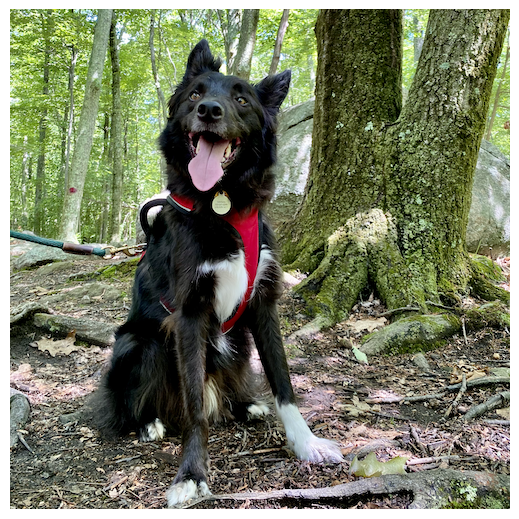

In [32]:
sns.dogplot()

In [33]:
seq_all[1].seq

Seq('MTLGNYIFQEVQRT')

In [34]:

# Take the sequences from the johnathan iterations
john_sequences = [s for s in seq_all if s.description.startswith('Johnatan')]
john_ids = [s.id for s in john_sequences]
john_iterations = [s.description for s in john_sequences]
john_lengths = [len(s.seq) for s in john_sequences]

# Put them all in a df where columns are ids, iteration, and length
df_john = pd.DataFrame({
    'seq_a': "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA",
    'seq_b': [str(s.seq) for s in john_sequences]
})

df_john_1_decoy = df_john.iloc[0:150]
df_john_2_decoy = df_john.iloc[150:]


df_john.to_csv('/FastHome/gyula/data/Johnatan_seq/john_sequences_decoy.csv', index=False)

In [35]:
john_sequences

[SeqRecord(seq=Seq('TLGERILAEVNK'), id='Johnatan_i1_1th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('SLGDTILEEVMK'), id='Johnatan_i1_2th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('SLGDTILNEVMK'), id='Johnatan_i1_3th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('TLGERILEEVNK'), id='Johnatan_i1_4th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('SLGQEILKEVEK'), id='Johnatan_i1_5th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('DMEKLTKDAYDALMS'), id='Johnatan_i1_6th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('DPEDVEATLKKAL'), id='Johnatan_i1_7th_rank', name='<unknown name>', description='Johnatan_i1', dbxrefs=[]),
 SeqRecord(seq=Seq('DLKELGEMLRSL'), id='Johnatan_i1_8th_rank', name='<unknown name>', description='Johnatan_i1', d

In [36]:
first_iter_mmpbsa = pd.read_csv("/home/kunzj/report/data/first_df_metrics_md_sim.csv").mmpbsa
second_iter_mmpbsa = pd.read_csv("/home/kunzj/report/data/second_df_metrics_md_sim.csv").mmpbsa
third_iter_mmpbsa = pd.read_csv("/home/kunzj/report/data/third_df_metrics_md_sim.csv").mmpbsa

In [37]:
johnatan_mmpbsa = pd.concat([first_iter_mmpbsa, second_iter_mmpbsa, third_iter_mmpbsa], ignore_index=True)
for i, s in enumerate(john_sequences):
    s.dbxrefs = johnatan_mmpbsa.iloc[i]


johnatan_mmpbsa


0     -60.670444
1     -64.455556
2     -62.511111
3     -61.568222
4     -65.880444
         ...    
301   -65.032889
302   -85.446444
303   -64.531778
304   -64.341556
305   -69.954667
Name: mmpbsa, Length: 306, dtype: float64

In [38]:
J_seqlist = [str(i.seq) for i in john_sequences]
J_seqlist
johnatan_mmpbsa


df_johnatan_mmpbsa = pd.DataFrame({
    'Target': "EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFGT",
    'proteina': J_seqlist,
    'Y': johnatan_mmpbsa.values
})
df_johnatan_mmpbsa
df_johnatan_mmpbsa.to_csv("/FastHome/gyula/data/Johnatan_seq/johnathan_seq_mmpbsa.csv")

In [39]:
center, dist = find_central_sequence(john_sequences, True)

In [40]:
reducer = umap.UMAP(metric='precomputed', n_neighbors=10)
# Generate the low-dimen
# sional embedding
embedding = reducer.fit_transform(dist)

/FastHome/gyula/anaconda3/envs/gyula_env/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


In [41]:


df_umap = pd.DataFrame({
    'id': [s.id for s in john_sequences],
    "mmpbsa": [str(s.dbxrefs) for s in john_sequences],
    "mmpbsa": [float(s.dbxrefs) for s in john_sequences],
    'iteration': [s.description for s in john_sequences],
    'UMAP1': embedding[:,0],
    'UMAP2': embedding[:,1],
    'length': [len(s.seq) for s in john_sequences]
})


df_umap_first_2 = df_umap.iloc[0:204,]
df_umap_first_2

,id,mmpbsa,iteration,UMAP1,UMAP2,length
0,Johnatan_i1_1th_rank,-60.670444,Johnatan_i1,6.702829,8.319598,12
1,Johnatan_i1_2th_rank,-64.455556,Johnatan_i1,7.946195,5.988465,12
2,Johnatan_i1_3th_rank,-62.511111,Johnatan_i1,6.678611,7.106148,12
3,Johnatan_i1_4th_rank,-61.568222,Johnatan_i1,8.514485,6.844156,12
4,Johnatan_i1_5th_rank,-65.880444,Johnatan_i1,7.247480,6.521286,12
...,...,...,...,...,...,...
199,Johnatan_i2_98th_rank,-67.412222,Johnatan_i2,7.018177,5.556215,15
200,Johnatan_i2_99th_rank,-69.751556,Johnatan_i2,6.709991,6.736913,14
201,Johnatan_i2_100th_rank,-63.164222,Johnatan_i2,9.958342,6.466256,15
202,Johnatan_i2_101th_rank,-73.852889,Johnatan_i2,8.291773,7.533355,14


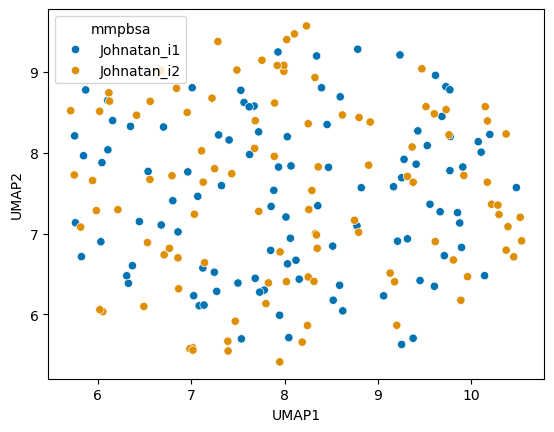

In [42]:
sns.scatterplot(data=df_umap_first_2, x='UMAP1', y='UMAP2', hue='iteration')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title='mmpbsa')
plt.show()

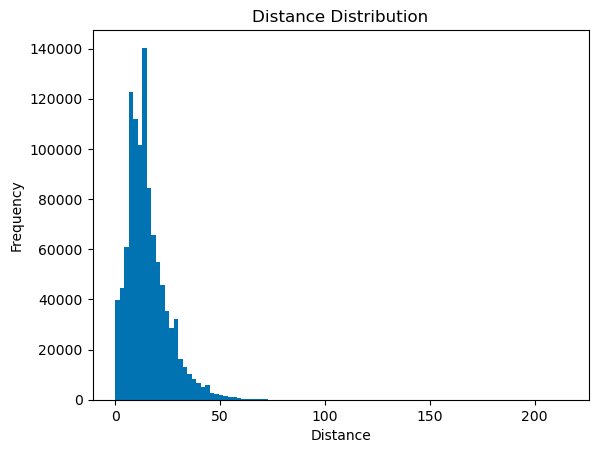

In [43]:
plt.hist(distance_matrix.flatten(), bins=100)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distance Distribution")
plt.show()

In [44]:
balm_ppi_pred = pd.read_csv("/FastHome/gyula/Affinity_preds/balm_batch_results_JOHNATAN_1.csv")
balm_ppi_pred_trimmed = pd.concat(
    [pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_trimmed.csv"),
     pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_trimmed_2.csv")]
)

balm_ppi_pred_bh_only = pd.concat(
    [pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_BH_ONLY.csv"),
     pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_BH_ONLY_2.csv")]
)

balm_ppi_pred_trimmed_low_bound = pd.concat(
    [pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_john_seq_1_trimmed_low_bounds.csv"),
     pd.read_csv("/FastHome/gyula/data/Johnatan_seq/john_seq_pred/balm_batch_results_john_seq_2_trimmed_low_bounds.csv")]
)






balm_ppi_pred_trimmed_low_bound

,seq_a,seq_b,pKd,Cosine
0,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,TLGERILAEVNK,7.6796,-0.296881
1,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,SLGDTILEEVMK,7.4880,-0.317048
2,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,SLGDTILNEVMK,7.8513,-0.278806
3,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,TLGERILEEVNK,7.8436,-0.279616
4,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,SLGQEILKEVEK,6.9783,-0.370709
...,...,...,...,...
151,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,STTALWRELADSL,7.5452,-0.311027
152,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,HHMSMWEYMEKKVMS,7.2066,-0.346672
153,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,SPLRKKIEETLS,7.7715,-0.287211
154,EQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSEC...,MSVISKWRELADEL,8.2494,-0.236908


In [45]:
balm_ppi_pred.pKd


0      29.3175
1      28.7760
2      30.4294
3      30.0010
4      26.8117
        ...   
301    29.2564
302    28.0330
303    30.1171
304    32.2514
305    31.9781
Name: pKd, Length: 306, dtype: float64

In [46]:
johnatan_mmpbsa

0     -60.670444
1     -64.455556
2     -62.511111
3     -61.568222
4     -65.880444
         ...    
301   -65.032889
302   -85.446444
303   -64.531778
304   -64.341556
305   -69.954667
Name: mmpbsa, Length: 306, dtype: float64

In [47]:
import pandas as pd
import numpy as np

def convert_pkd_to_kj_mol(pkd_series: pd.Series, t_kelvin: float = 298.15) -> pd.Series:
    """
    Converts a pandas Series of pKd values to binding free energy (ΔG) in kcal/mol.

    Parameters
    ----------
    pkd_series : pd.Series
        Negative decadic logarithm of the dissociation constant.
    t_kelvin : float, optional
        System temperature in Kelvin (default is 298.15).

    Returns
    -------
    pd.Series
        Calculated ΔG values in kcal/mol.
    """

    # Ideal gas constant in kcal / (K * mol)
    r_const = 1.9872036e-3

    # Calculate conversion factor: -R * T * ln(10)
    factor = -r_const * t_kelvin * np.log(10)

    # Vectorized multiplication
    dg_series = pkd_series * factor * 4.184

    return dg_series


balm_ppi_pred_kcal_mol

NameError: name 'balm_ppi_pred_kcal_mol' is not defined

In [2]:
balm_ppi_pred_bh_only_kj_mol = convert_pkd_to_kj_mol(balm_ppi_pred_bh_only.pKd)
balm_ppi_pred_trimmed_kj_mol = convert_pkd_to_kj_mol(balm_ppi_pred_trimmed.pKd)

balm_ppi_pred_trimmed_low_bound_kj_mol = convert_pkd_to_kj_mol(balm_ppi_pred_trimmed_low_bound.pKd)
decoy = pd.read_csv("/FastHome/gyula/data/Johnatan_seq/balm_batch_results_decoy.csv")
decoy_kj_mol = convert_pkd_to_kj_mol(decoy.pKd)

NameError: name 'convert_pkd_to_kj_mol' is not defined

In [1]:
johnatan_mmpbsa

NameError: name 'johnatan_mmpbsa' is not defined

Text(0.5, 0, 'prediction (kJ/mol)')

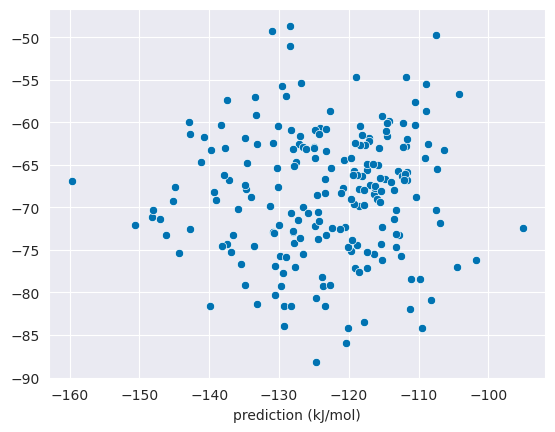

In [64]:



sns.scatterplot(x = balm_ppi_pred_trimmed_kj_mol[0:204], y =
johnatan_mmpbsa.values[0:204])
plt.xlabel("prediction (kJ/mol)")

In [126]:
decoy

0       9.4039
1       9.3732
2       9.7062
3       9.5852
4       8.9117
        ...   
301     9.5644
302     9.5822
303     9.6184
304    10.1313
305    10.0268
Name: pKd, Length: 306, dtype: float64

In [74]:

array1 = np.asarray(johnatan_mmpbsa.values, dtype=float)
array2 = np.asarray(balm_ppi_pred_kcal_mol.values, dtype=float)

# Execute correlation computation
matrix = np.corrcoef(array1[0:204], array2[0:204])

In [75]:
matrix

array([[1.        , 0.06054897],
       [0.06054897, 1.        ]])

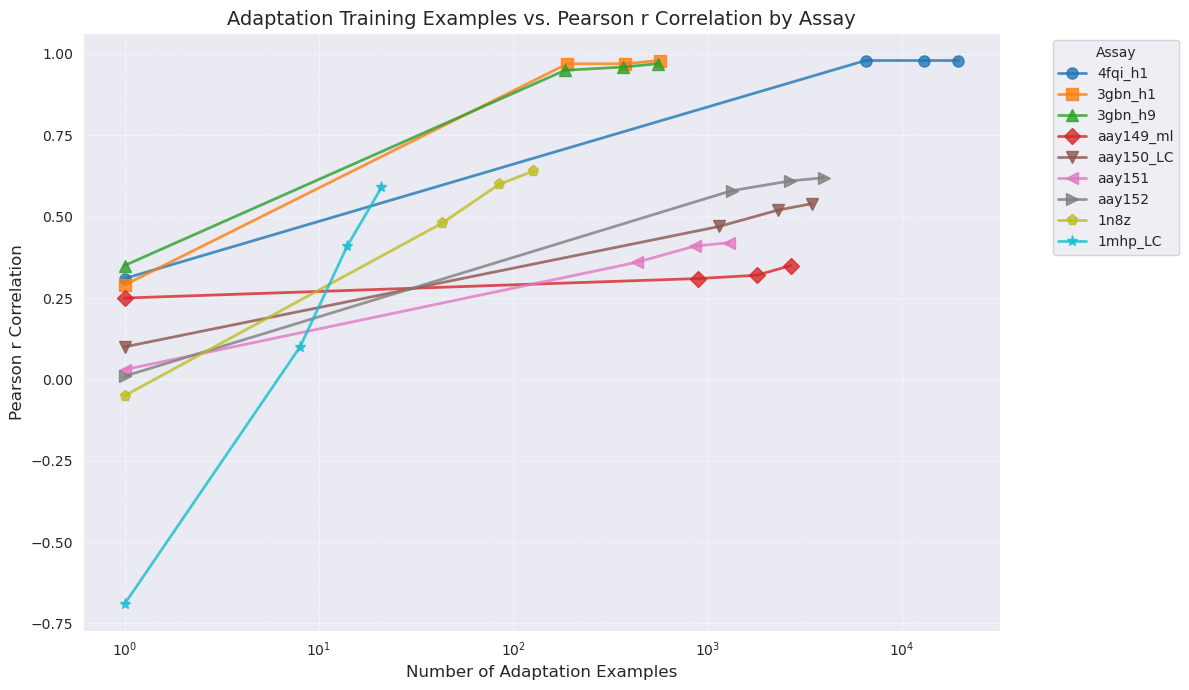

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Original Vectors
data_points = [
    0, 6509, 13019, 19528, 0, 189, 377, 566, 0, 184, 368, 553,
    0, 895, 1791, 2686, 0, 1147, 2295, 3442, 0, 432, 864, 1296,
    0, 1332, 2665, 3997, 0, 42, 84, 126, 0, 7, 13, 20
]
data_points = np.array(data_points) + 1

pearson_r = [
    0.31, 0.98, 0.98, 0.98, 0.29, 0.97, 0.97, 0.98, 0.35, 0.95, 0.96, 0.97,
    0.25, 0.31, 0.32, 0.35, 0.10, 0.47, 0.52, 0.54, 0.03, 0.36, 0.41, 0.42,
    0.01, 0.58, 0.61, 0.62, -0.05, 0.48, 0.60, 0.64, -0.69, 0.10, 0.41, 0.59
]

assay_names = [
    '4fqi_h1', '3gbn_h1', '3gbn_h9', 'aay149_ml',
    'aay150_LC', 'aay151', 'aay152', '1n8z', '1mhp_LC'
]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']
colors = plt.cm.tab10(np.linspace(0, 1, len(assay_names)))

fig, ax = plt.subplots(figsize=(12, 7))

# Loop through data in chunks of 4 (0%, 10%, 20%, 30%)
for i in range(len(assay_names)):
    x = data_points[i*4 : (i+1)*4]
    y = pearson_r[i*4 : (i+1)*4]

    ax.plot(x, y, marker=markers[i], markersize=8, color=colors[i],
            linewidth=2, label=assay_names[i], alpha=0.8)

# Format plot
ax.set_title('Adaptation Training Examples vs. Pearson r Correlation by Assay', fontsize=14)
ax.set_xlabel('Number of Adaptation Examples', fontsize=12)
ax.set_ylabel('Pearson r Correlation', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Assay', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.set_xscale('log')
plt.tight_layout()
plt.savefig('scatter_plot_connected.png', bbox_inches='tight')